# EMA 6938 - Data Science for Materials
## Week 10 Lab Notebook: Feature Engineering, Model Tuning, and Structure-Property Mapping

**Name:** Ryan Tuggle  
**Date:** 7/16/2026  
**Kernel:** Python (matds)

---

**Chapters:** Sandfeld Ch. 16  
**Format:** Parts A-F in-class - due **Sunday 11:59 PM**   
**Dataset:** `data/week10_mp_mapping.csv` (instructor-provided)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.

This notebook has 7 parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 1 |
| B | Leakage-Aware Split | Lecture Segment 2 |
| C | Tune a Random Forest | Lecture Segment 4 |
| D | Feature Importance & Selection | Lecture Segment 1 |
| E | UMAP Projection | Lecture Segment 5 |
| F | White-Space Discovery | Lecture Segment 5 |
| G | Reflection & Midterm Bridge | All segments |

This notebook is also the template for the midterm reproduce-and-extend task.

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** I used MS copilot for the purpose of helping to draft some of the code. I used it particularly for the RF model cells and plot. 

In [2]:
# Cell 0 — Environment check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (GroupKFold, cross_val_score,
    RandomizedSearchCV, learning_curve, train_test_split)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from pymatgen.core import Composition
import warnings; warnings.filterwarnings('ignore')
from sklearn.exceptions import SkipTestWarning
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

try:
    import umap
    print("umap-learn OK")
except ImportError:
    print("WARNING: umap-learn not found - run: pip install umap-learn")

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print("Core imports OK")

umap-learn OK
Core imports OK


---
## Part A - Load & Inspect

### A1: Load the dataset

In [3]:
# Cell A1
# LECTURE DEMO
df = pd.read_csv('data/week10_mp_mapping.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns[:8].tolist()} ...")
print(f"\nBand gap - mean: {df['band_gap'].mean():.2f} eV, std: {df['band_gap'].std():.2f}")
print(f"Formation energy - mean: {df['Ef_eV_atom'].mean():.3f} eV/atom")
print(f"\nCrystal systems:\n{df['crystal_system'].value_counts().head(6)}")

Shape: (8000, 140)

Columns: ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'volume_A3', 'density_g_cm3', 'crystal_system', 'composition'] ...

Band gap - mean: 1.68 eV, std: 1.56
Formation energy - mean: -2.425 eV/atom

Crystal systems:
crystal_system
Monoclinic      2774
Orthorhombic    1609
Triclinic       1576
Trigonal         681
Tetragonal       634
Cubic            470
Name: count, dtype: int64


### A2: Set up the feature matrix X and target y

In [4]:
# Cell A2
# LECTURE DEMO
non_feature_cols = ['mp_id','formula','band_gap','Ef_eV_atom','volume_A3',
                    'density_g_cm3','crystal_system','spacegroup','composition',
                    'is_metallic','is_insulating','is_theoretical']
feature_cols = [c for c in df.columns
                if c not in non_feature_cols and df[c].dtype in ['float64','float32']]
print(f"MAGPIE features: {len(feature_cols)}")

X_all = df[feature_cols].values
y_all = df['band_gap'].values

mask  = ~(np.isnan(X_all).any(axis=1) | np.isnan(y_all))
X_all = X_all[mask]; y_all = y_all[mask]
df_clean = df[mask].reset_index(drop=True)
print(f"Final shape: {X_all.shape}  ({(~mask).sum()} rows dropped)")

MAGPIE features: 132
Final shape: (8000, 132)  (0 rows dropped)


### A3: Compute reduced formula for GroupKFold groups

> GroupKFold needs a group label for each sample. We use the reduced formula so that all polymorphs (e.g. TiO2 rutile and anatase) always end up in the same fold.

In [5]:
# Cell A3
# LECTURE DEMO
df_clean['reduced_formula'] = df_clean['formula'].apply(
    lambda f: Composition(f).reduced_formula)

n_unique = df_clean['reduced_formula'].nunique()
n_total  = len(df_clean)
print(f"Total entries:          {n_total:,}")
print(f"Unique reduced formulas:{n_unique:,}")
print(f"Avg entries per formula:{n_total/n_unique:.1f}")
print(f"\nMost frequent reduced formulas:")
print(df_clean['reduced_formula'].value_counts().head(8))

Total entries:          8,000
Unique reduced formulas:6,086
Avg entries per formula:1.3

Most frequent reduced formulas:
reduced_formula
Li9Mn2Co5O16    91
SiO2            58
Li7Mn5O12       25
Li7Mn4CoO12     20
LiMnPO4         19
Li6V3P8O29      18
LiCoPO4         18
Li3V3P8O29      18
Name: count, dtype: int64


---
## Part B - Leakage-Aware Split

### B1: GroupKFold split

In [6]:
# Cell B1
# LECTURE DEMO
groups = df_clean['reduced_formula'].values
gkf    = GroupKFold(n_splits=5)

# Extract fold 0 for Parts C–F
folds = list(gkf.split(X_all, y_all, groups))
train_idx, test_idx = folds[0]

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
groups_train    = groups[train_idx]

print(f"Fold 0 - Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train mean band_gap: {y_train.mean():.3f} eV")
print(f"Test  mean band_gap: {y_test.mean():.3f} eV")

# Confirm no composition overlap between train and test
train_formulas = set(df_clean.iloc[train_idx]['reduced_formula'])
test_formulas  = set(df_clean.iloc[test_idx]['reduced_formula'])
overlap = train_formulas & test_formulas
print(f"\nComposition overlap between train and test: {len(overlap)} formulas")
print("(Should be 0 - that is the point of GroupKFold)")

Fold 0 - Train: 6,400  |  Test: 1,600
Train mean band_gap: 1.695 eV
Test  mean band_gap: 1.606 eV

Composition overlap between train and test: 0 formulas
(Should be 0 - that is the point of GroupKFold)


### B2: Compare random split vs. GroupKFold - the leakage gap

In [7]:
# Cell B2
# LECTURE DEMO
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf",     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED))
])

# Random 5-fold CV
r2_random = cross_val_score(pipe, X_all, y_all, cv=5, scoring="r2")

# GroupKFold — no composition overlap
r2_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="r2")

print("=" * 50)
print(f"Random 5-fold CV R2:  {r2_random.mean():.3f} ± {r2_random.std():.3f}")
print(f"GroupKFold R2:        {r2_group.mean():.3f}  ± {r2_group.std():.3f}")
print(f"Inflation from random split: {r2_random.mean() - r2_group.mean():.3f}")
print("=" * 50)
print("\nThe gap above is the composition leakage component.")
print("GroupKFold is the honest estimate of generalisation to new compositions.")

Random 5-fold CV R2:  0.667 ± 0.026
GroupKFold R2:        0.581  ± 0.020
Inflation from random split: 0.085

The gap above is the composition leakage component.
GroupKFold is the honest estimate of generalisation to new compositions.


### B3: Scale within the training fold only

In [8]:
# Cell B3
# LECTURE DEMO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test

print(f"X_train_scaled mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"X_test_scaled  mean: {X_test_scaled.mean():.4f}  (not guaranteed ~0)")

X_train_scaled mean: 0.0000  std: 0.9653
X_test_scaled  mean: 0.0210  (not guaranteed ~0)


---
## Part C - Hyperparameter Tuning

### C1: Default RF baseline

In [9]:
# Cell C1
# LECTURE DEMO
rf_default = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED)
rf_default.fit(X_train_scaled, y_train)
y_pred_default = rf_default.predict(X_test_scaled)

r2_def  = r2_score(y_test, y_pred_default)
mae_def = mean_absolute_error(y_test, y_pred_default)
rmse_def= np.sqrt(mean_squared_error(y_test, y_pred_default))

print("Default RF:")
print(f"  R2:   {r2_def:.3f}")
print(f"  MAE:  {mae_def:.3f} eV")
print(f"  RMSE: {rmse_def:.3f} eV")

Default RF:
  R2:   0.545
  MAE:  0.752 eV
  RMSE: 0.992 eV


### C2: RandomizedSearchCV with GroupKFold inner CV

In [10]:
# Cell C2 — Hyperparameter tuning
# LECTURE DEMO
# Set TUNER to choose your method:
#   'random'  — RandomizedSearchCV (sklearn, always available)
#   'optuna'  — Bayesian optimisation via Optuna (pip install optuna)
#
# Both produce the same interface — C3 works unchanged either way.

TUNER = 'random'   # ← change to 'optuna' to use Bayesian optimisation

if TUNER == 'random':
    from sklearn.model_selection import RandomizedSearchCV

    param_dist = {
        "rf__n_estimators":     [100, 200, 300, 500],
        "rf__max_depth":        [None, 5, 10, 20],
        "rf__min_samples_leaf": [1, 2, 5],
        "rf__max_features":     ["sqrt", "log2", 0.3],
    }

    rscv = RandomizedSearchCV(
        pipe, param_dist, n_iter=30,
        cv=GroupKFold(n_splits=5),
        scoring="r2", n_jobs=-1, random_state=SEED, verbose=0
    )
    rscv.fit(X_train, y_train, groups=groups_train)

    best_model    = rscv
    best_params   = rscv.best_params_
    best_cv_score = rscv.best_score_
    print("Method: RandomizedSearchCV (30 random trials)")

elif TUNER == 'optuna':
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    except ImportError:
        raise ImportError(
            "Optuna not installed. Run:  pip install optuna\n"
            "Or set TUNER = 'random' above to use RandomizedSearchCV instead."
        )
    from sklearn.model_selection import cross_val_score

    def objective(trial):
        params = {
            "rf__n_estimators":     trial.suggest_int("n_estimators", 100, 500, step=100),
            "rf__max_depth":        trial.suggest_int("max_depth", 3, 20),
            "rf__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "rf__max_features":     trial.suggest_float("max_features", 0.1, 0.9),
        }
        pipe.set_params(**params)
        scores = cross_val_score(
            pipe, X_train, y_train,
            cv=GroupKFold(n_splits=5),
            groups=groups_train,
            scoring="r2", n_jobs=-1
        )
        return scores.mean()

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=30, show_progress_bar=False)

    best_trial_params = {f"rf__{k}": v for k, v in study.best_params.items()}
    pipe.set_params(**best_trial_params)
    pipe.fit(X_train, y_train)

    class _OptunaTuned:
        def __init__(self, pipeline, params, score):
            self.best_params_ = params
            self.best_score_  = score
            self._pipe        = pipeline
        def predict(self, X): return self._pipe.predict(X)

    best_model    = _OptunaTuned(pipe, best_trial_params, study.best_value)
    best_params   = best_trial_params
    best_cv_score = study.best_value
    print("Method: Optuna Bayesian optimisation (30 trials, TPE sampler)")

else:
    raise ValueError(f"TUNER must be 'random' or 'optuna', got {TUNER!r}")

print(f"Best params:  {best_params}")
print(f"Best CV R\u00b2:   {best_cv_score:.3f}")

Method: RandomizedSearchCV (30 random trials)
Best params:  {'rf__n_estimators': 500, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.3, 'rf__max_depth': None}
Best CV R²:   0.577


### C3: Evaluate tuned RF on test fold

                      Model    R2   MAE  RMSE
                 Default RF 0.545 0.752 0.992
Tuned RF (RandomizedSearch) 0.552 0.747 0.983


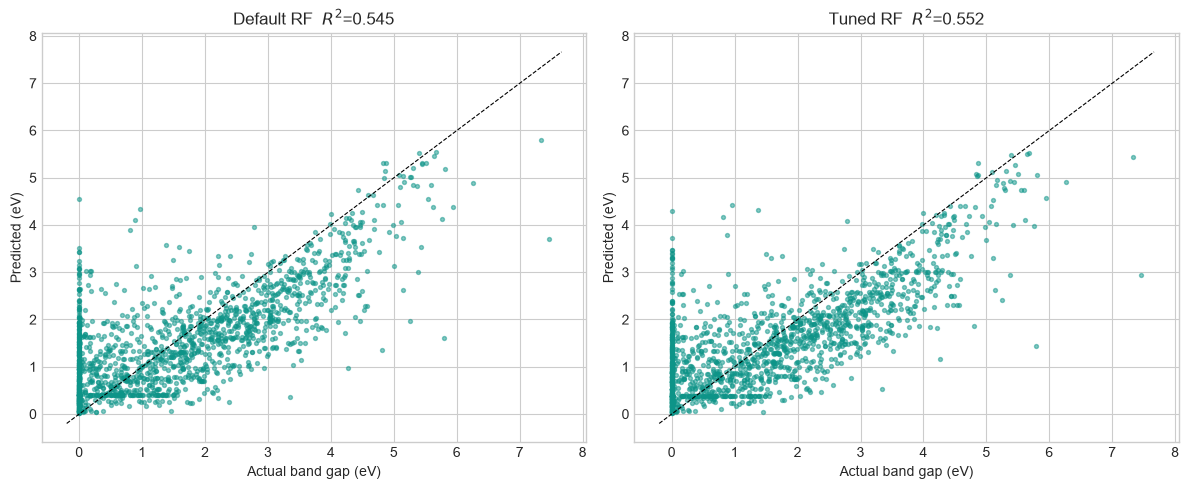

In [11]:
# Cell C3
# LECTURE DEMO
y_pred_tuned = best_model.predict(X_test)
r2_tuned   = r2_score(y_test, y_pred_tuned)
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

comparison = pd.DataFrame({
    'Model':  ['Default RF', 'Tuned RF (RandomizedSearch)'],
    'R2':     [round(r2_def,3),   round(r2_tuned,3)],
    'MAE':    [round(mae_def,3),  round(mae_tuned,3)],
    'RMSE':   [round(rmse_def,3), round(rmse_tuned,3)],
})
print(comparison.to_string(index=False))

# Prediction scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes,
    [y_pred_default, y_pred_tuned],
    ['Default RF', 'Tuned RF']):
    ax.scatter(y_test, preds, s=8, alpha=0.5, color='#0D9488')
    lim = [min(y_test.min(), preds.min())-0.2, max(y_test.max(), preds.max())+0.2]
    ax.plot(lim, lim, 'k--', lw=0.8)
    ax.set_xlabel('Actual band gap (eV)'); ax.set_ylabel('Predicted (eV)')
    ax.set_title(f'{title}  $R^2$={r2_score(y_test,preds):.3f}')
plt.tight_layout(); plt.savefig('C3_prediction_scatter.png', dpi=150); plt.show()

### C4: Task - Learning curve for tuned RF

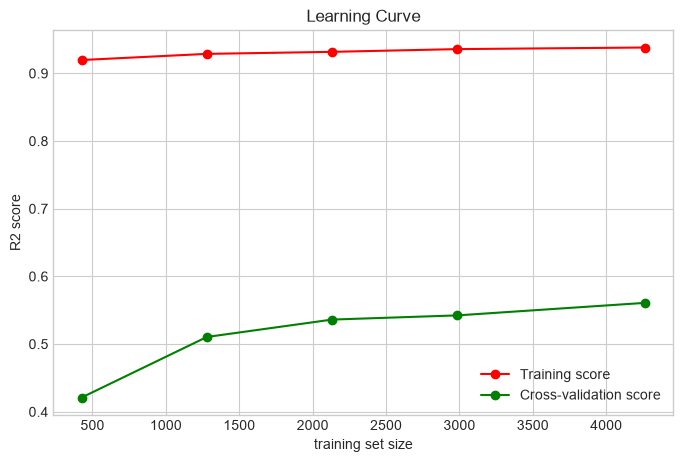

In [12]:
# Cell C4
# TASK CELL
# YOUR CODE: use sklearn.model_selection.learning_curve
from sklearn.base import clone

from sklearn.model_selection import learning_curve
est_lc = clone(pipe).set_params(**best_model.best_params_)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=est_lc,
    X=X_train,
    y=y_train,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0],
    cv=GroupKFold(3),
    groups=groups_train,
    scoring="r2"
)
fig,ax = plt.subplots(figsize=(8,5))
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
ax.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
ax.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
ax.set_xlabel('training set size')
ax.set_ylabel('R2 score')
ax.set_title('Learning Curve')
ax.legend(loc='best')
plt.savefig('C4_learning_curve.png', dpi=150)
plt.show()
# Plot train R2 and CV R2 vs. training set size (10%, 30%, 50%, 70%, 100%)
# cv = GroupKFold(3); groups = groups_train; scoring = "r2"
# Save as C4_learning_curve.png
# What regime (high bias / high variance) does the curve show?

**Reflection C4 - fill in this cell:**

Looking at the learning curve: does the model appear to be in a high-bias or high-variance regime? What would you do to improve performance given what the curve shows?

The model appears to be in a high-variance regime as it fits the train data well, but predictions on validation folds are worse. This is indicative of overfitting on the train set. To improve the performance I would lower the max_depth on the trees to bring the scores closer together and increase the dataset size. 

---
## Part D - Feature Importance & Selection

### D1: Top 20 feature importances

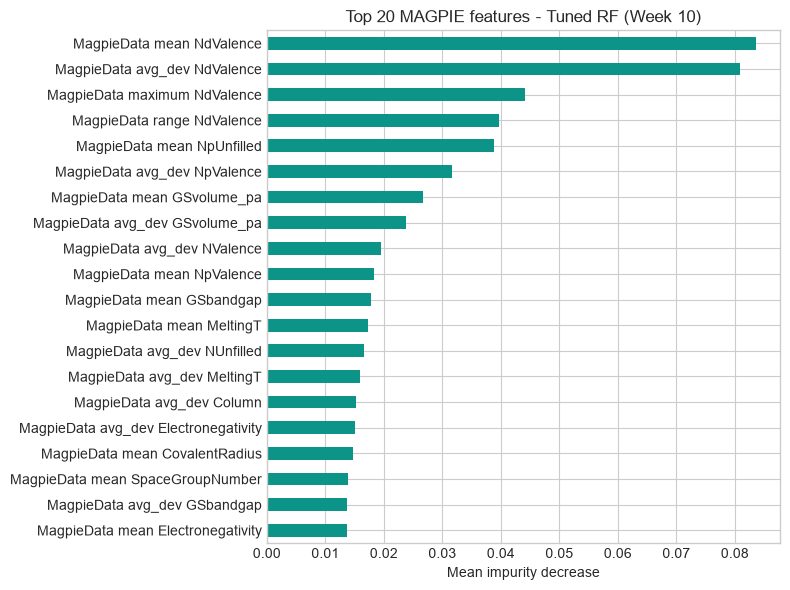

Top 10 features:
MagpieData mean NdValence         0.0835
MagpieData avg_dev NdValence      0.0808
MagpieData maximum NdValence      0.0441
MagpieData range NdValence        0.0397
MagpieData mean NpUnfilled        0.0388
MagpieData avg_dev NpValence      0.0317
MagpieData mean GSvolume_pa       0.0267
MagpieData avg_dev GSvolume_pa    0.0238
MagpieData avg_dev NValence       0.0195
MagpieData mean NpValence         0.0184
dtype: float64


In [13]:
# Cell D1 — Extract the trained RF from the best estimator (inside the Pipeline)
# LECTURE DEMO
best_rf = rscv.best_estimator_.named_steps['rf']
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', color='#0D9488', ax=ax)
ax.set_xlabel('Mean impurity decrease')
ax.set_title('Top 20 MAGPIE features - Tuned RF (Week 10)')
plt.tight_layout()
plt.savefig('D1_feature_importance.png', dpi=150)
plt.show()

print("Top 10 features:")
print(top20.head(10).round(4))

### D2: Correlation filter - remove redundant features

In [14]:
# Cell D2
# LECTURE DEMO
X_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
corr_matrix = X_df.corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns to drop: those with |r| > 0.95 with any other column
cols_to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
print(f"Features removed by correlation filter (|r|>0.95): {len(cols_to_drop)}")
print(f"Features remaining: {len(feature_cols) - len(cols_to_drop)}")

feature_cols_filtered = [c for c in feature_cols if c not in cols_to_drop]
X_train_filt = X_train_scaled[:, [feature_cols.index(c) for c in feature_cols_filtered]]
X_test_filt  = X_test_scaled[:,  [feature_cols.index(c) for c in feature_cols_filtered]]

Features removed by correlation filter (|r|>0.95): 43
Features remaining: 89


### D3: Task - RF on filtered feature set

In [15]:
# Cell D3
# TASK CELL
# YOUR CODE: train the tuned RF (best_params from C2) on X_train_filt
est_lc = clone(pipe).set_params(**best_model.best_params_)
est_lc.fit(X_train_filt, y_train)
est_lc.predict(X_test_filt)
comparison_df = pd.DataFrame([{'Model': 'Filtered RF', 'R2': r2_score(y_test, est_lc.predict(X_test_filt)), 'MAE': mean_absolute_error(y_test, est_lc.predict(X_test_filt)), 'RMSE': np.sqrt(mean_squared_error(y_test, est_lc.predict(X_test_filt)))}])
comparison_table = pd.concat([comparison, comparison_df], ignore_index=True)
print(comparison_table.to_string(index=False))
# Evaluate on X_test_filt
# Add a row to the comparison table from C3
# Is the performance change (+ or -) worth the feature reduction?

                      Model       R2      MAE     RMSE
                 Default RF 0.545000 0.752000 0.992000
Tuned RF (RandomizedSearch) 0.552000 0.747000 0.983000
                Filtered RF 0.551274 0.749333 0.984338


**Reflection D3 - fill in this cell:**

After removing correlated features, did R2 increase, decrease, or stay the same? What does this tell you about the information in the removed features? Were they truly redundant or were they carrying independent signal?

After removing correlated features, the R2 decreased from the Tuned RF model. This indicates that the features removed after filtering for features having high correlation had information that helped the model with predictions on validation folds. While the difference in R2 is marginal, the features were not completeley redundant if they increased the R2. RF unlike linear models can benefit from having highly correlated features becuase each tree has a random subset of features so both highly correlated features can still inform the model. 

---
## Part E - UMAP Projection

### E1: Fit UMAP on training data (PCA-10 first for speed)

In [16]:
# Cell E1
# LECTURE DEMO
from sklearn.decomposition import PCA

# PCA-10 first for speed and noise reduction
pca10 = PCA(n_components=10, random_state=SEED)
X_train_pca = pca10.fit_transform(X_train_scaled)

print(f"PCA-10 cumulative variance: {pca10.explained_variance_ratio_.sum():.1%}")

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
embedding_train = reducer.fit_transform(X_train_pca)

np.save('E1_umap_train.npy', embedding_train)
print(f"Training embedding shape: {embedding_train.shape}")

PCA-10 cumulative variance: 75.9%
Training embedding shape: (6400, 2)


### E2: UMAP colored by actual band gap

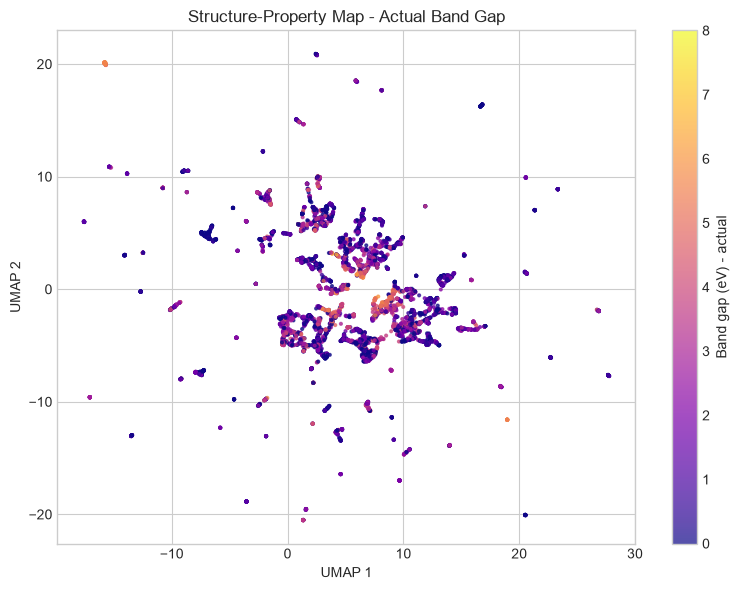

In [17]:
# Cell E2
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embedding_train[:,0], embedding_train[:,1],
                c=y_train, cmap='plasma', vmin=0, vmax=8, s=4, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Band gap (eV) - actual')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('Structure-Property Map - Actual Band Gap')
plt.tight_layout()
plt.savefig('E2_umap_actual.png', dpi=150)
plt.show()

### E3: UMAP colored by model predictions

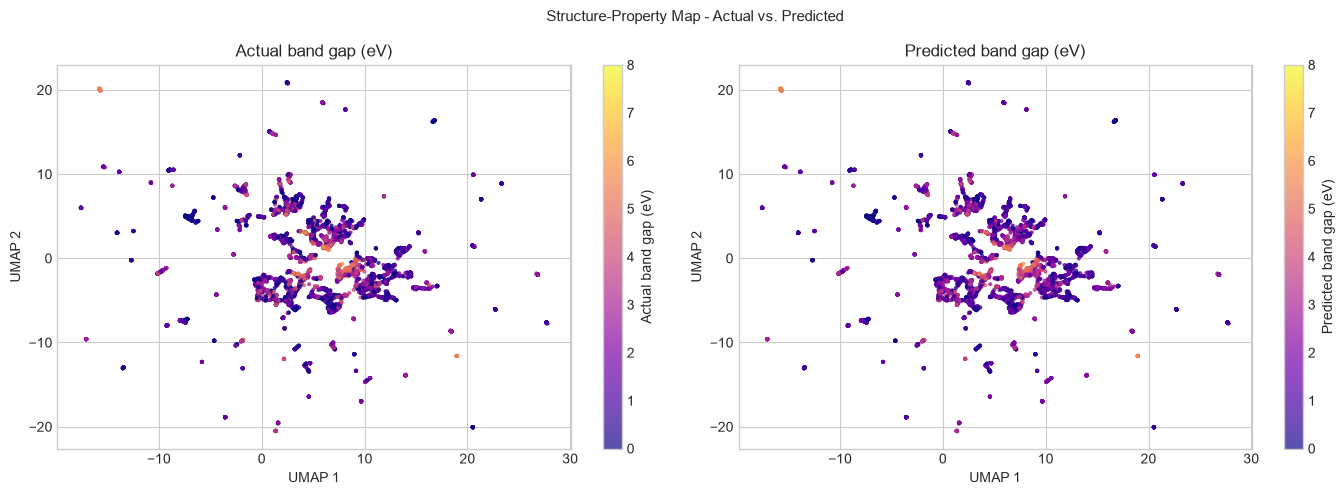

Regions where actual and predicted differ strongly = where the model struggles most.


In [27]:
# Cell E3 — Predict band_gap for all training points with the tuned RF
# LECTURE DEMO
y_train_pred = rscv.best_estimator_.predict(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vals, title in zip(axes,
    [y_train, y_train_pred],
    ['Actual band gap (eV)', 'Predicted band gap (eV)']):
    sc = ax.scatter(embedding_train[:,0], embedding_train[:,1],
                    c=vals, cmap='plasma', vmin=0, vmax=8, s=4, alpha=0.7)
    plt.colorbar(sc, ax=ax, label=title)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.set_title(title)

plt.suptitle('Structure-Property Map - Actual vs. Predicted', fontsize=11)
plt.tight_layout()
plt.savefig('E3_umap_actual_vs_predicted.png', dpi=150)
plt.show()

print("Regions where actual and predicted differ strongly = where the model struggles most.")

---
## Part F - White-Space Discovery

### F1: Generate candidate compositions

In [18]:
# Cell F1 — Generate candidate binary oxide compositions not in the training set
# Elements: common oxide-forming metals + main group
candidate_elements = [
    'Li','Na','K','Mg','Ca','Sr','Ba',
    'Al','Ga','In','Tl',
    'Si','Ge','Sn','Pb',
    'Ti','Zr','Hf','V','Nb','Ta','Cr','Mo','W',
    'Mn','Fe','Co','Ni','Cu','Zn'
]

candidates = []
for el in candidate_elements:
    for ox in [2, 3, 4]:  # MO, M2O3, MO2 stoichiometries
        if ox == 2:
            formula = f"{el}O"
        elif ox == 3:
            formula = f"{el}2O3"
        else:
            formula = f"{el}O2"
        try:
            comp = Composition(formula)
            rf   = comp.reduced_formula
            if rf not in set(df_clean['reduced_formula']):  # not in training set
                candidates.append({'formula': formula, 'reduced_formula': rf})
        except:
            pass

df_cand = pd.DataFrame(candidates).drop_duplicates('reduced_formula')
print(f"Generated {len(df_cand)} candidate compositions not in training data")
print(df_cand.head(10))

Generated 55 candidate compositions not in training data
  formula reduced_formula
0   Li2O3           Li2O3
1    LiO2            LiO2
2     NaO           Na2O2
3   Na2O3           Na2O3
4      KO            K2O2
5    K2O3            K2O3
6   Mg2O3           Mg2O3
7    MgO2            MgO2
8   Ca2O3           Ca2O3
9    CaO2            CaO2


### F2: Featurise candidates and project onto UMAP

StrToComposition:   0%|          | 0/55 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/55 [00:00<?, ?it/s]

Successfully featurised: 55 candidates


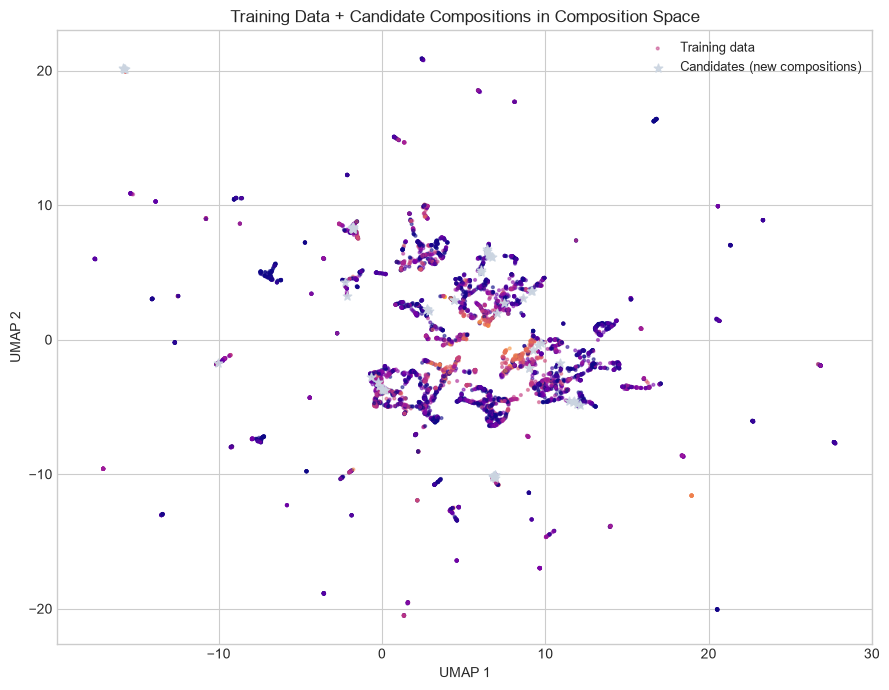

In [19]:
# Cell F2
# LECTURE DEMO
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

stc = StrToComposition(target_col_id='composition')
df_cand_feat = stc.featurize_dataframe(df_cand.copy(), 'formula', ignore_errors=True)
ep = ElementProperty.from_preset('magpie')
df_cand_feat = ep.featurize_dataframe(df_cand_feat, 'composition', ignore_errors=True)
df_cand_feat = df_cand_feat.dropna(subset=feature_cols)

print(f"Successfully featurised: {len(df_cand_feat)} candidates")

X_cand = df_cand_feat[feature_cols].values
X_cand_scaled = scaler.transform(X_cand)       # use training scaler
X_cand_pca    = pca10.transform(X_cand_scaled) # use training PCA
embedding_cand = reducer.transform(X_cand_pca) # project onto training UMAP
np.save('F2_umap_candidates.npy', embedding_cand)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(embedding_train[:,0], embedding_train[:,1],
           c=y_train, cmap='plasma', vmin=0, vmax=8, s=4, alpha=0.5, label='Training data')
ax.scatter(embedding_cand[:,0], embedding_cand[:,1],
           c='#CBD5E1', s=40, marker='*', alpha=0.9, label='Candidates (new compositions)')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('Training Data + Candidate Compositions in Composition Space')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('F2_umap_candidates.png', dpi=150)
plt.show()

### F3: Flag isolated candidates - white-space identification

In [20]:
# Cell F3
# LECTURE DEMO
from sklearn.neighbors import NearestNeighbors

# Distance from each candidate to its nearest training point (in PCA-10 space)
nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_train_pca)
distances, _ = nn.kneighbors(X_cand_pca)
distances = distances.ravel()

# Flag candidates in sparse regions (distance > 95th percentile of training pairwise distances)
threshold = np.percentile(distances, 95)
isolated  = distances > threshold

print(f"Distance threshold (95th percentile): {threshold:.3f}")
print(f"Isolated candidates (in white space): {isolated.sum()} / {len(df_cand_feat)}")

df_cand_feat['nn_distance'] = distances
df_cand_feat['in_whitespace'] = isolated
print("\nTop 5 most isolated candidates:")
print(df_cand_feat.nlargest(5, 'nn_distance')[['formula','reduced_formula','nn_distance']])

Distance threshold (95th percentile): 5.018
Isolated candidates (in white space): 3 / 55

Top 5 most isolated candidates:
   formula reduced_formula  nn_distance
37     TaO             TaO     7.589638
42      WO              WO     6.979626
33     HfO             HfO     6.367282
19     TlO             TlO     4.439392
13     AlO             AlO     4.173873


### F4: Task - predict band gap for isolated candidates

In [21]:
# Cell F4 — Predict band_gap for all candidates with the tuned RF
# TASk CELL
y_cand_pred = rscv.best_estimator_.predict(df_cand_feat[feature_cols].values)
df_cand_feat['predicted_band_gap'] = y_cand_pred

# Focus on the 3 most isolated candidates
top3_isolated = df_cand_feat.nlargest(3, 'nn_distance')[
    ['formula','reduced_formula','nn_distance','predicted_band_gap']]
print("Top 3 most isolated candidates with predicted band gap:")
print(top3_isolated.to_string(index=False))

# YOUR TASK: Answer in a markdown cell below —
# Are these predictions trustworthy?
# A candidate far from all training points is an extrapolation.
# What additional evidence would you need before taking this prediction seriously?

Top 3 most isolated candidates with predicted band gap:
formula reduced_formula  nn_distance  predicted_band_gap
    TaO             TaO     7.589638            1.195820
     WO              WO     6.979626            1.259414
    HfO             HfO     6.367282            1.190260


In [24]:
# Candidate points in your "interesting" region (adjust bounds as needed)
mask_region = (embedding_cand[:, 0] >= 0) & (embedding_cand[:, 0] <= 10)

region_df = df_cand_feat.loc[mask_region, ['formula', 'reduced_formula', 'predicted_band_gap', 'nn_distance']].copy()
region_df = region_df.sort_values('predicted_band_gap', ascending=False)

print(f"Candidates in region: {len(region_df)}")
print(region_df.head(20).to_string(index=False))

Candidates in region: 32
formula reduced_formula  predicted_band_gap  nn_distance
  Sr2O3           Sr2O3            2.972020     2.684026
  Ca2O3           Ca2O3            2.863568     2.473998
   SrO2            SrO2            2.810542     2.391996
  Mg2O3           Mg2O3            2.708503     2.631571
  Ba2O3           Ba2O3            2.521102     0.997975
  Na2O3           Na2O3            2.461613     3.165765
   CaO2            CaO2            2.381856     2.216696
  Li2O3           Li2O3            2.229721     2.740293
  Ge2O3           Ge2O3            2.186196     0.873310
   K2O3            K2O3            2.131323     1.662085
     KO            K2O2            2.115230     2.743349
   MgO2            MgO2            2.088184     2.479187
    GeO             GeO            2.044892     2.916153
   GaO2            GaO2            2.032578     0.787125
    GaO             GaO            1.822880     2.957952
   LiO2            LiO2            1.784436     2.686461
   ZnO

**Reflection F4 - fill in this cell:**

For the top 3 isolated candidates: are their predicted band gaps trustworthy? Explain the concept of interpolation vs. extrapolation in the context of the UMAP map, and describe what evidence (experimental or computational) would be needed to validate the prediction.

For the top three isolated candidates the predicted bandgap is not trustworthy. These points were above the 95th percentile in terms of distance from the nearest neighbor which means the random forest prediction of the bandgap is an extrapolation instead of an interpolation. To validate this prediction one could run DFT predictions for the bandgap or synthesize these compounds and characterize the bandgap with UV spectroscopy. 

---
## Part G - Reflection & Midterm Bridge

### G1: R2 gap — composition leakage

In 3–4 sentences: What was the R2 gap between random 5-fold CV and GroupKFold in Part B? What does this gap mean physically in terms of what the model learned vs. what we want it to generalise to? Is a model that performs well on random CV but poorly on GroupKFold useful for materials discovery?

The R2 gap between the random 5-fold CV and the Groupkfold CV was 0.086. This gap means that the model learned to predict the bandgap based on the features, but that it was also predicting based on memorizing the formula and the asscociated bandgap and then applying it to the same formula in the test set. This means that the random model won't generalise as well when it can't train on the same formulas as will be in the test set. A model that performs well on random CV but poorly on GroupKFold won't be as useful in materials discovery since it will be seeing completley new formulas it hasn't trained on. GroupKFold is a more realistic test of generalization to unseen compositions.

### G2: White-space region - scientific hypothesis

In 3–4 sentences: Identify the white-space region you find most scientifically interesting in your UMAP map. Name the candidate composition family it corresponds to. State one physical reason why new materials in that region might have useful band gap properties and one reason why the model's prediction there might be unreliable.

The region I find most interesting in the white-space region of the UMAP map is that region centered around the wide gap oxides in the 0-10 region of the UMAP 1 axis. The candidate composition family this area belongs to are mostly alkalai and alkaline-earth binary oxides. New materials in that region might have useful bandgap properties because they will yield large bandgaps making them better at operating at higher voltages and more extreme temperatures in power electronics. One reason the model's prediction could be unreliable is that lack of other datapoints in that white space to help confirm the bandgap is not being extrapolated. 

### G3: Midterm bridge

In 2–3 sentences: The pipeline you built today (fetch → featurise → GroupKFold tune → UMAP → overlay → white-space) is the template for the midterm. Which step will you modify for your "extend" component — and why did you choose that step?

For my midterm I modified the Groupkfold component. While I was not doing multiple folds in part B, I was holding back some crystal systems for the test set so that the model could not train on them, which is like the GroupKFold method. I chose this step because I wanted to see how much leakage was inflating the accuracy of the model. 

---
## Day 2

> **This section is covered on Day 2**

### Demo 1 - GroupKFold vs. random split: quantifying the leakage gap

Random 5-fold CV:      mean $R^2$=0.666  std=0.026
GroupKFold CV:         mean $R^2$=0.580   std=0.021
Leakage gap:           0.086


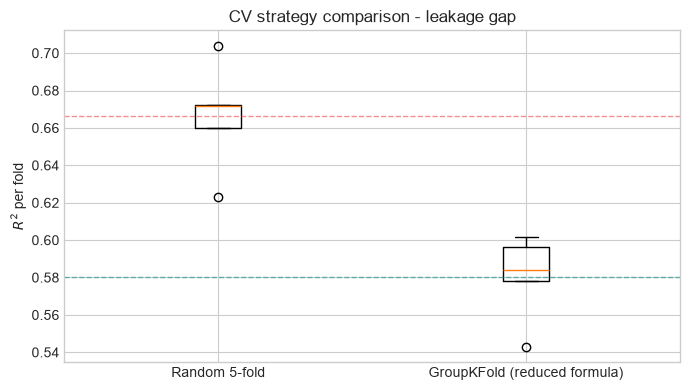

In [22]:
# Cell DEMO 1 - Compare CV strategies across multiple folds
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_val_score

rf_base = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

# Random 5-fold CV
r2_random = cross_val_score(rf_base, X_all, y_all, cv=5, scoring='r2')

# GroupKFold by reduced formula
r2_group  = cross_val_score(rf_base, X_all, y_all,
                             cv=GroupKFold(5), groups=groups,
                             scoring='r2')

print(f"Random 5-fold CV:      mean $R^2$={r2_random.mean():.3f}  std={r2_random.std():.3f}")
print(f"GroupKFold CV:         mean $R^2$={r2_group.mean():.3f}   std={r2_group.std():.3f}")
print(f"Leakage gap:           {r2_random.mean() - r2_group.mean():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([r2_random, r2_group], tick_labels=['Random 5-fold', 'GroupKFold (reduced formula)'])
ax.set_ylabel('$R^2$ per fold'); ax.set_title('CV strategy comparison - leakage gap')
ax.axhline(r2_random.mean(), color='#EF4444', ls='--', lw=1, alpha=0.6)
ax.axhline(r2_group.mean(),  color='#0D9488', ls='--', lw=1, alpha=0.6)
plt.tight_layout()
plt.savefig('Day2_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Demo 2 - White-space trustworthiness: extrapolation vs. interpolation

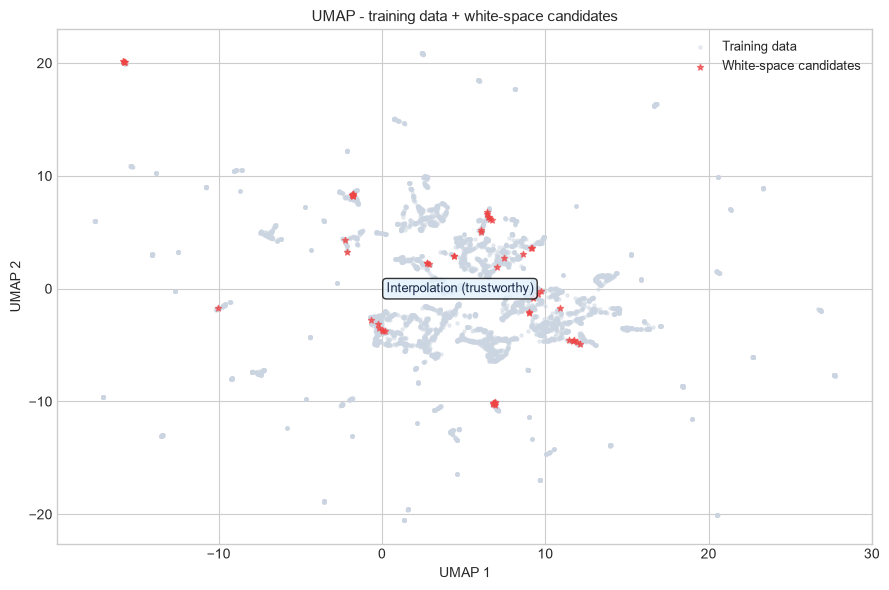

In [23]:
# Cell DEMO 2 — Annotated white-space UMAP: trustworthy vs. extrapolation regions
# LECTURE DEMO
# Load UMAP embeddings from Part E (must have run Part E first)
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(embedding_train[:,0], embedding_train[:,1],
                    c='#CBD5E1', s=5, alpha=0.4, label='Training data')
cd = ax.scatter(embedding_cand[:,0], embedding_cand[:,1],
                   c='#EF4444', s=20, alpha=0.7,
                   marker='*', label='White-space candidates')

# Annotate trust regions manually
ax.text(embedding_train[:,0].mean(), embedding_train[:,1].mean(),
            'Interpolation (trustworthy)', fontsize=9,
            ha='center', color='#1C2B4A',
            bbox=dict(boxstyle='round', fc='#E3F2FD', alpha=0.8))

ax.set_title('UMAP - training data + white-space candidates', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Day2_whitespace_trust.png', dpi=150, bbox_inches='tight')
plt.show()

### Demo 3 - Midterm bridge: what a good reproduce-and-extend looks like
**Instructor-led discussion - no code cell**

The midterm assigns you to reproduce the key quantitative result of an ML-for-materials paper,
then extend it with one methodological improvement.

**The reproduce step:** Load or reconstruct the dataset. Implement the same feature set and model.
Apply the same CV strategy. Report the same metrics. Discuss any discrepancy between your result
and the paper's. Discrepancies are interesting, not failures.

**The extend step (choose one):**
- Change random CV to GroupKFold - quantify the leakage gap
- Add one structure-based feature the paper did not use
- Apply Lasso feature selection and report which features survive
- Produce a learning curve the paper did not show

**The metric that matters:** Your extension must change at least one reported number
(R2, MAE, n_features) and you must explain physically why it changed.

**Day 2 Discussion questions:**

1. From Demo 1: how large is the leakage gap between random CV and GroupKFold for your dataset? If a paper reports $R^2$=0.92 with random CV, what would you expect with GroupKFold?

2. From Demo 2: which white-space candidates are most isolated from the training data? Are model predictions in those regions trustworthy? What would you need to trust them?

3. Midterm planning: which of the four extension options (CV strategy / structure feature / Lasso / learning curve) is most relevant to the paper you have been assigned? Which one will give you the most interesting finding?

---
## Submission Checklist

Before submitting, confirm all cells have been executed:

- [ ] B2: Random vs. GroupKFold comparison printed (with inflation gap)
- [ ] C3: Comparison table (Default RF vs. Tuned RF) + prediction scatter saved
- [ ] C4: Learning curve task completed and reflection filled in
- [ ] D1: Feature importance plot saved
- [ ] D3: Filtered RF task completed and reflection filled in
- [ ] E2–E3: Both UMAP scatters saved (actual + predicted)
- [ ] F2: Candidate UMAP overlay saved
- [ ] F3: Isolated candidates identified and listed
- [ ] F4: Prediction trustworthiness reflection filled in
- [ ] G1–G3: All reflection cells answered
- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week10.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.
**Submit via Canvas by Sunday 11:59 PM.**
**Midterm due: Sunday 11:59 PM - see the midterm notebook on GitHub.**